HOW TO USE

1. At the end, there is a call to the function run_metropolis_loop. There you modify the parameters of the run.

2. Progress is saved in a checkpoint file called "mace_checkpoint.npz". To start from scratch, just delete this file.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import time
from mace.calculators import mace_mp
from ase.optimize import BFGS, FIRE
from ase.io import read, write
from ase import Atoms
from ase.build import sort
from IPython.display import display, clear_output
from scipy.constants import k, eV

kB = k / eV  # Converts J/K -> eV/KV

/home/inglorious/anaconda3/lib/python3.13/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [2]:
# 1. Read the POSCAR file directly into an ASE Atoms object
# ASE automatically handles elements, counts, coordinates, and cell vectors!
structure = read("A05-36.vasp", format="vasp")
num_atoms = len(structure)

print(f"Successfully loaded POSCAR!")
print(f"Chemical formula: {structure.get_chemical_formula()}")
print(f"Total number of atoms: {len(structure)}")
print(f"Unit cell volume: {structure.get_volume():.2f} Å³")

print("Periodic Boundary Conditions (x, y, z):", structure.pbc)

Successfully loaded POSCAR!
Chemical formula: Mo12Ta12Ti12V12W12
Total number of atoms: 60
Unit cell volume: 919.93 Å³
Periodic Boundary Conditions (x, y, z): [ True  True  True]


In [3]:
def save_checkpoint(filename, step, atoms, energy, accepted, plotter=None):
    """Saves simulation state, energy history, and structure to an .npz file."""
    steps_list = plotter.steps if plotter else []
    energies_list = plotter.energies if plotter else []

    np.savez_compressed(
        filename,
        step=step,
        energy=energy,
        accepted=accepted,
        positions=atoms.get_positions(),
        cell=atoms.get_cell().array,
        pbc=atoms.get_pbc(),
        symbols=np.array(atoms.get_chemical_symbols()),
        steps_list=np.array(steps_list, dtype=int),
        energies_list=np.array(energies_list, dtype=float)
    )
    print(f" [Checkpoint saved: '{filename}' at step {step}]")

In [4]:
def load_checkpoint(filename):
    """
    Loads state from .npz file.
    Returns (data_dict, atoms_object) if exists, else None.
    """
    if not os.path.exists(filename):
        return None
    
    data = np.load(filename)
    
    # Reconstruct ASE Atoms object with original cell & positions
    atoms = Atoms(
        symbols=data["symbols"].tolist(),
        positions=data["positions"],
        cell=data["cell"],
        pbc=data["pbc"]
    )
    
    ckpt_dict = {
        "step": int(data["step"]),
        "energy": float(data["energy"]),
        "accepted": int(data["accepted"]),
        "steps_list": data["steps_list"].tolist(),
        "energies_list": data["energies_list"].tolist()
    }
    
    return ckpt_dict, atoms

In [5]:
from ase.build import sort

def save_snapshot(atoms, step, output_dir="snapshots", prefix="POSCAR"):
    """Saves the current atomic structure as a VASP POSCAR file."""
    os.makedirs(output_dir, exist_ok=True)
    filename = os.path.join(output_dir, f"{prefix}_step_{step:04d}")
    
    # Save using ASE's VASP writer
    sorted_atoms = sort(atoms)
    write(filename, sorted_atoms, format="vasp")
    print(f" [Snapshot saved: '{filename}']")

In [6]:
model_size = "small" # or use the downloaded/trained model "/content/mace-mp-0b3-medium.model" #"mace_mp_0b3" #"medium"          # "small", "medium", or "large"
dispersion = False             # set True if you want D3 dispersion correction

mace_calc = mace_mp(
    model=model_size,
    dispersion=dispersion,
    default_dtype="float32",   # faster and usually sufficient
    device='cuda'  # use it with gpu
)

def get_mace_energy(atoms, calculator):
    """
    Attaches the MACE calculator to an Atoms object 
    and returns its total potential energy in eV.
    """
    atoms.calc = calculator
    return atoms.get_potential_energy()

energy = get_mace_energy(structure, mace_calc)
print(f"Total Potential Energy: {energy:.4f} eV")

Using Materials Project MACE for MACECalculator with /home/inglorious/.cache/mace/20231210mace128L0_energy_epoch249model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/home/inglorious/anaconda3/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Total Potential Energy: -632.5206 eV


In [7]:
fmax = 0.005                    # force convergence criterion (eV/Å) — 0.05 is good for most cases
steps = 200                    # maximum optimization steps

def relax_structure(atoms, calculator, fmax=fmax, max_steps=steps):
    """
    Relaxes atomic positions using BFGS until the maximum force 
    component on any atom is below `fmax` (eV/Å).
    Returns the relaxed structure and its final energy.
    """
    relaxed_atoms = atoms.copy()
    relaxed_atoms.calc = calculator
    
    # Run local BFGS relaxation
    opt = BFGS(relaxed_atoms, logfile=None)
    #opt = BFGS(relaxed_atoms, trajectory='relaxation.traj')
    opt.run(fmax=fmax, steps=max_steps)
    
    final_energy = relaxed_atoms.get_potential_energy()
    return relaxed_atoms, final_energy

relaxed_structure, relaxed_energy = relax_structure(structure, mace_calc)
print(f"Relaxed Energy: {relaxed_energy:.4f} eV")

Relaxed Energy: -633.8217 eV


In [8]:
def get_moving_average(data, window_size=10):
    if len(data) < window_size:
        return np.mean(data)  # Average of available points before hitting full window size
    return np.mean(data[-window_size:])

In [9]:
from IPython.display import display, clear_output

class LivePlotter:
    def __init__(self, window_size=10):
        self.window_size = window_size
        self.steps = []
        self.energies = []

    def set_history(self, steps, energies):
        """Restores history from a checkpoint seamlessly."""
        self.steps = list(steps)
        self.energies = list(energies)

    def update(self, step, energy):
        # Prevent duplicate step entries if resuming
        if len(self.steps) == 0 or self.steps[-1] != step:
            self.steps.append(step)
            self.energies.append(energy)
        else:
            self.energies[-1] = energy

        # Calculate moving average safely
        moving_avgs = [
            np.mean(self.energies[max(0, idx - self.window_size + 1): idx + 1])
            for idx in range(len(self.energies))
        ]
        
        # Redraw
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(7, 4))
        
        ax.plot(self.steps, self.energies, color='gray', alpha=0.4, label='Raw Energy (eV)')
#        ax.plot(self.steps, moving_avgs, 'r-', linewidth=2, label=f'{self.window_size}-Step Moving Avg')
        
        ax.set_xlabel('MC Step')
        ax.set_ylabel('Energy (eV)')
        ax.set_title('Metropolis MC Energy Track')
        ax.legend(loc='upper right')
        ax.grid(True, linestyle='--', alpha=0.6)
        
        display(fig)
        plt.close(fig)

In [10]:
def run_metropolis_loop(atoms, calculator, temp_k, total_steps, plotter=None, 
                         checkpoint_file="mc_checkpoint.npz", save_every=10, snapshot_every=20, snapshot_dir="snapshots"):
    beta = 1.0 / (kB * temp_k)
    
    # Check for existing checkpoint
    ckpt = load_checkpoint(checkpoint_file)
    if ckpt is not None:
        ckpt_dict, current_atoms = ckpt
        start_step = ckpt_dict["step"] + 1
        current_energy = ckpt_dict["energy"]
        accepted = ckpt_dict["accepted"]
        print(f"--> RESUMING from step {start_step} via {checkpoint_file}")
        
        if plotter is not None:
            plotter.set_history(ckpt_dict["steps_list"], ckpt_dict["energies_list"])
    else:
        start_step = 1
        accepted = 0
        current_atoms, current_energy = relax_structure(atoms, calculator)
        print("--> Starting FRESH simulation at step 1")

    # Main Metropolis loop
    for step in range(start_step, total_steps + 1):
        # Pick two atoms of distinct elements to swap
        n_atoms = len(current_atoms)
        i, j = np.random.choice(n_atoms, size=2, replace=False)
        while current_atoms.symbols[i] == current_atoms.symbols[j]:
            i, j = np.random.choice(n_atoms, size=2, replace=False)
            
        # Perform swap
        trial_atoms = current_atoms.copy()
        symbols = trial_atoms.get_chemical_symbols()
        symbols[i], symbols[j] = symbols[j], symbols[i]
        trial_atoms.set_chemical_symbols(symbols)
        
        # Local BFGS relaxation & potential energy calculation
        trial_atoms, trial_energy = relax_structure(trial_atoms, calculator)
        delta_e = trial_energy - current_energy
        
        # Metropolis acceptance check
        if delta_e <= 0 or np.random.rand() < np.exp(-beta * delta_e):
            current_atoms = trial_atoms
            current_energy = trial_energy
            accepted += 1
            status = "ACCEPTED"
        else:
            status = "REJECTED"
            
        print(f"Step {step:3d}/{total_steps} | {status} | ΔE: {delta_e:+.4f} eV | E: {current_energy:.4f} eV")

        # Update live plot canvas
        if plotter is not None:
            plotter.update(step, current_energy)

        # Save snapshot POSCAR
        if step % snapshot_every == 0:
            save_snapshot(current_atoms, step, output_dir=snapshot_dir)

        # Save checkpoint
        if step % save_every == 0:
            save_checkpoint(checkpoint_file, step, current_atoms, current_energy, accepted, plotter)

    print(f"\nDone! Final Acceptance Rate: {(accepted / total_steps) * 100:.1f}%")

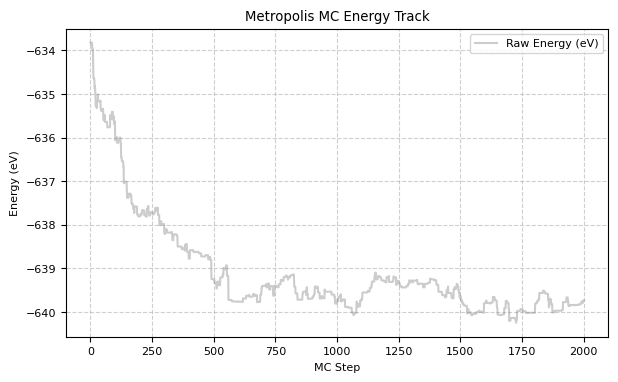

 [Snapshot saved: 'snapshots_mace/POSCAR_step_2000']
 [Checkpoint saved: 'mace_checkpoint.npz' at step 2000]

Done! Final Acceptance Rate: 19.8%


In [11]:
# Instantiate plotter separately
plotter = LivePlotter(window_size=100)

# Pass it into the loop (or pass plotter=None if you want to run headless/fast)
initial_structure = structure.copy()

run_metropolis_loop(
    atoms=initial_structure,
    calculator=mace_calc,
    temp_k=800,
    total_steps=2000,  # cumulative, as in Octopus
    plotter=plotter,
    checkpoint_file="mace_checkpoint.npz",
    save_every=50,
    snapshot_every=500,
    snapshot_dir="snapshots_mace"
)

HOW TO USE

1. At the end, there is a call to the function run_metropolis_loop. There you modify the parameters of the run.

2. Progress is saved in a checkpoint file called "mace_checkpoint.npz". To start from scratch, just delete this file.